In [ ]:
!pip install opencv-python matplotlib seaborn


In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mtcnn import MTCNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models


In [16]:
from google.colab import files
files.upload()




Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sobaannayyar","key":"12da3b499171ad8e3ede64da29d926bb"}'}

In [17]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [18]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images


Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
 94% 1.59G/1.68G [00:30<00:03, 26.3MB/s]
100% 1.68G/1.68G [00:30<00:00, 58.9MB/s]


In [19]:
!unzip -qq deepfake-and-real-images.zip -d data/


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

# ImageDataGenerator with rescaling and validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    'data/Dataset/Train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    'data/Dataset/Train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 112002 images belonging to 2 classes.
Found 28000 images belonging to 2 classes.


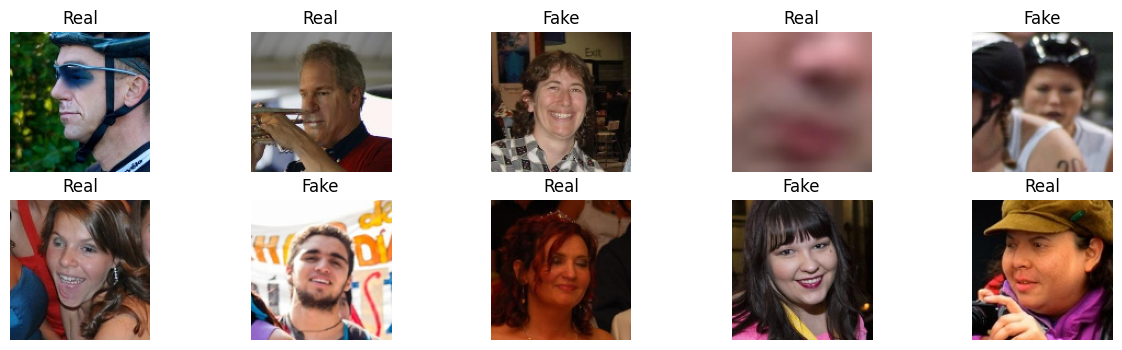

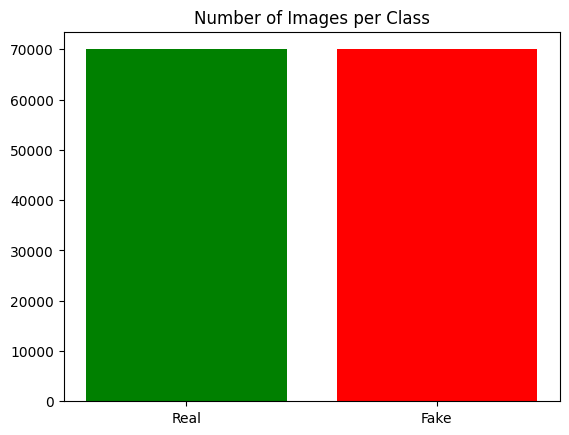

In [21]:
import matplotlib.pyplot as plt
import os

# Visualization of data and class distribution using a bar chart


def show_sample_images(generator, n=5):
    imgs, labels = next(generator)
    plt.figure(figsize=(15,4))
    for i in range(n*2):
        plt.subplot(2,n,i+1)
        plt.imshow(imgs[i])
        plt.title("Real" if labels[i]==0 else "Fake")
        plt.axis('off')
    plt.show()

show_sample_images(train_generator, n=5)

import numpy as np
class_counts = [len(os.listdir('data/Dataset/Train/Real')), len(os.listdir('data/Dataset/Train/Fake'))]
plt.bar(['Real', 'Fake'], class_counts, color=['green','red'])
plt.title("Number of Images per Class")
plt.show()


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: Real vs Fake
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)


Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3501/3501 ━━━━━━━━━━━━━━━━━━━━ 142s 39ms/step - accuracy: 0.7993 - loss: 0.4109 - val_accuracy: 0.9216 - val_loss: 0.1836
Epoch 2/3
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 134s 38ms/step - accuracy: 0.9273 - loss: 0.1781 - val_accuracy: 0.9337 - val_loss: 0.1590
Epoch 3/3
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 136s 39ms/step - accuracy: 0.9438 - loss: 0.1406 - val_accuracy: 0.9457 - val_loss: 0.1345


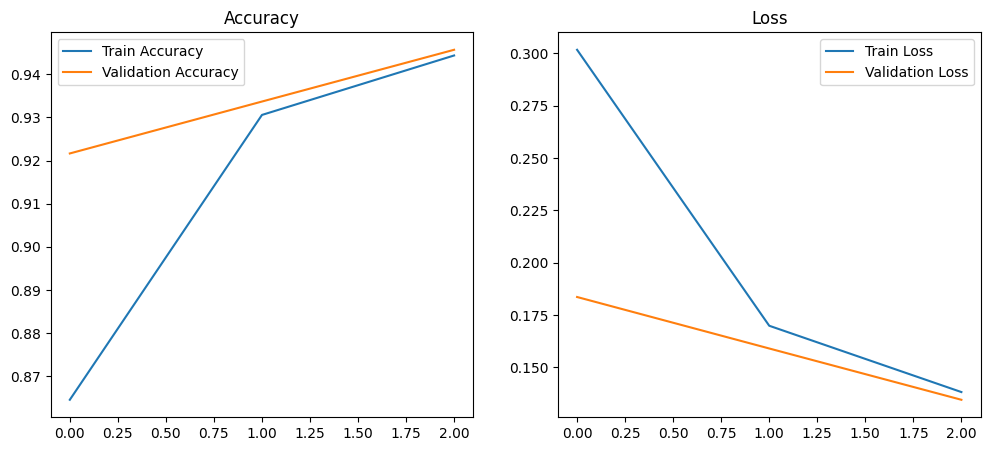

In [24]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.legend()

plt.show()


In [ ]:
import os

os.makedirs("/content/models", exist_ok=True)

model.save("/content/models/deepfake_detector.h5")
print("Model saved in /content/models/deepfake_detector.h5")


In [26]:
from google.colab import files
files.download("/content/models/deepfake_detector.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>